## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
import pandas as pd
import os
from PIL import Image
import copy
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Setup

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_SIZE = 224

In [ ]:
# set up model path (the latest model)
WEIGHTS_PATH = '../models/SSL_IME_Round3_0.70_F1Moist.pth'

# Paths for Unlabeled Images
unlabeled_dirs = [
    '/content/drive/MyDrive/Wound_Assessment/Dataset/data_wound_seg/test_images/',
    '/content/drive/MyDrive/Wound_Assessment/Dataset/data_wound_seg/train_images/',
    '../data/original_data_and_mask/Images/'
]

# Path for all the masks
mask_dir = '../data/tsegnet_mask/'

# Path for processed images for SSL training
PROCESSED_SSL_DIR = '../data/segmented_images/SSL_Processed_Final/'

# Path for final Pseudo-Label CSV
# SAVE_PATH_CSV = '/content/drive/MyDrive/Wound_Assessment/SSL_WeightedCrossEntropy_pred_results/SSL_Pseudo_Labels.csv'
SAVE_PATH_CONF_CSV = '../Training_Master_Sheets/Training_Master_Round4_0.90.csv'

## Pre-processing

In [ ]:
# Resize with padding
def resize_with_padding(image, target_size=224):
    h, w = image.shape[:2]
    scale = min(target_size / w, target_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    x_off, y_off = (target_size - new_w) // 2, (target_size - new_h) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas

def preprocess_for_ssl(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None: return None

    # Sync sizes
    if img.shape[:2] != mask.shape[:2]:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 1. Background Suppression (The Overlap)
    masked_img = cv2.bitwise_and(img, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR))

    # 2. BBox Crop
    rows, cols = np.any(mask, axis=1), np.any(mask, axis=0)
    if not np.any(rows) or not np.any(cols): return None
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    # 3. Final Padding & Resize
    return resize_with_padding(masked_img[y_min:y_max, x_min:x_max], TARGET_SIZE)


## Verify Data Pipeline

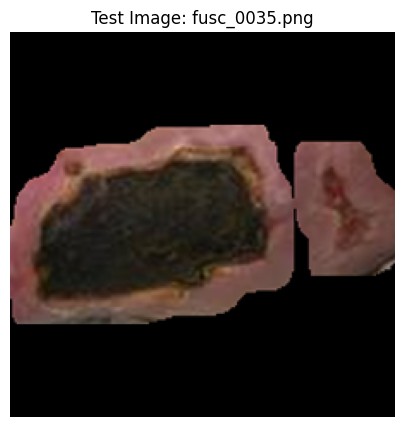

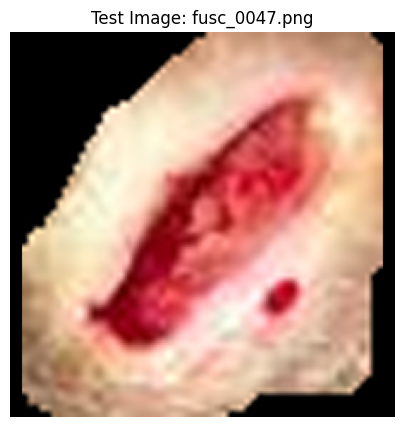

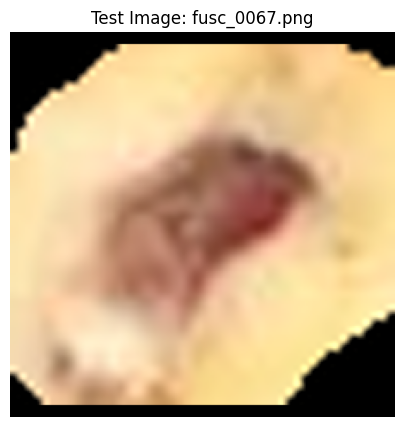

In [ ]:
# A small test loop
test_count = 0
for folder in unlabeled_dirs:
    if test_count >= 3: break

    for filename in os.listdir(folder):
        if test_count >= 3: break

        base_name = os.path.splitext(filename)[0]
        img_path = os.path.join(folder, filename)
        mask_path = os.path.join(mask_dir, base_name + ".png")

        if os.path.exists(mask_path):
            output = preprocess_for_ssl(img_path, mask_path)
            if output is not None:
              # save the processed output
              save_file_path = os.path.join(PROCESSED_SSL_DIR, filename)
              cv2.imwrite(save_file_path, output)

              # Visualization
              plt.figure(figsize=(5,5))
              plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
              plt.title(f"Test Image: {filename}")
              plt.axis('off')
              plt.show()
              test_count += 1

## Define Multi-Task Model Architecture

In [ ]:
class ProposedMultiTaskModel(nn.Module):
    def __init__(self):
        super(ProposedMultiTaskModel, self).__init__()

        # 1. Load EfficientNet-B0 with Pre-trained Weights
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # 2. Extract the number of input features going into the classifier
        num_ftrs = self.backbone.classifier[1].in_features

        # 3. Remove the original single-task classifier
        self.backbone.classifier = nn.Identity()

        # 4. Define 3 separate 'Heads' for I.M.E. tasks

        # Infection Head
        self.head_inf = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)   # Infection (0=No, 1=Yes)
        )

        # Moisture Head
        self.head_moist = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 3)   # Moisture (0=Dry, 1=Moist, 2=Wet)
        )

        # Edge Head
        self.head_edge = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)   # Edge (0=No, 1=Yes)
        )

    def forward(self, x):
        # Feature extraction
        features = self.backbone(x)

        # Multi-task outputs
        out_inf = self.head_inf(features)
        out_moist = self.head_moist(features)
        out_edge = self.head_edge(features)

        return out_inf, out_moist, out_edge


In [ ]:
# Initialize model
model = ProposedMultiTaskModel().to(DEVICE)
print(" Multi-Task EfficientNet-B0 Model initialized.")

# Load the state_dict
try:
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))

    # 4. CRITICAL: Set to Evaluation Mode
    # This disables Dropout(0.3) so the Teacher gives stable predictions
    model.eval()
    print("Model loaded successfully and set to Evaluation mode.")
except Exception as e:
    print(f"Error loading weights: {e}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 164MB/s]


 Multi-Task EfficientNet-B0 Model initialized.
Model loaded successfully and set to Evaluation mode.


## Resize and Normalization Data

In [ ]:
# Standard normalization values for EfficientNet/ImageNet
inference_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Pseudo-Labeling Loop

In [ ]:
# results = []

# for folder in unlabeled_dirs:
#     print(f"Processing folder: {folder}")
#     for filename in tqdm(os.listdir(folder)):
#         # 1. Path Setup
#         base_name = os.path.splitext(filename)[0]
#         img_path = os.path.join(folder, filename)
#         mask_path = os.path.join(mask_dir, base_name + ".png")

#         # 2. Check if mask exists
#         if os.path.exists(mask_path):
#             # 3. Preprocess (Crop, Overlap, Pad)
#             processed_img = preprocess_for_ssl(img_path, mask_path)
#             if processed_img is None: continue

#             # 4. Save the processed image to Drive for the Student
#             save_file_path = os.path.join(PROCESSED_SSL_DIR, filename)
#             cv2.imwrite(save_file_path, processed_img)

#             # 5. Teacher Prediction (Inference)
#             # Prepare tensor for the model
#             input_tensor = inference_transform(processed_img).unsqueeze(0).to(DEVICE)

#             with torch.no_grad():
#                 out_inf, out_moist, out_edge = model(input_tensor)

#                 # Get the class with the highest probability
#                 pred_inf = torch.argmax(out_inf, dim=1).item()
#                 pred_moist = torch.argmax(out_moist, dim=1).item()
#                 pred_edge = torch.argmax(out_edge, dim=1).item()

#             # 6. Store result for the CSV
#             results.append({
#                 'filename': filename,
#                 'inf_label': pred_inf,
#                 'moist_label': pred_moist,
#                 'edge_label': pred_edge
#             })

# # 7. Save the final Pseudo-Label CSV
# pd.DataFrame(results).to_csv(SAVE_PATH_CSV, index=False)
# print(f"\n {len(results)} pseudo-labels saved to {SAVE_PATH_CSV}")

Processing folder: /content/drive/MyDrive/Wound_Assessment/Dataset/data_wound_seg/test_images/


100%|██████████| 487/487 [17:51<00:00,  2.20s/it]


Processing folder: /content/drive/MyDrive/Wound_Assessment/Dataset/data_wound_seg/train_images/


100%|██████████| 2110/2110 [1:16:38<00:00,  2.18s/it]


Processing folder: /content/drive/MyDrive/Wound_Assessment/Dataset/data_wound_seg/SSL_manual_seg/


100%|██████████| 12/12 [00:27<00:00,  2.26s/it]


 2609 pseudo-labels saved to /content/drive/MyDrive/Wound_Assessment/SSL_Pseudo_Labels.csv


In [ ]:
# 1. Initialize the results list
inference_results = []
model.eval()

# 2. Get the list of processsed images
processed_filenames = [f for f in os.listdir(PROCESSED_SSL_DIR) if f.endswith(('.jpg', '.png'))]

print(f" Starting Inference on {len(processed_filenames)} processed images...")

for filename in tqdm(processed_filenames):
    img_path = os.path.join(PROCESSED_SSL_DIR, filename)

    # 3. Fast Load
    try:

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        input_tensor = inference_transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            out_inf, out_moist, out_edge = model(input_tensor)

            # 4. Get Softmax Probabilities for Confidence
            prob_inf = F.softmax(out_inf, dim=1)
            prob_moist = F.softmax(out_moist, dim=1)
            prob_edge = F.softmax(out_edge, dim=1)

            # 5. Get Label and Confidence Score
            conf_inf, pred_inf = torch.max(prob_inf, dim=1)
            conf_moist, pred_moist = torch.max(prob_moist, dim=1)
            conf_edge, pred_edge = torch.max(prob_edge, dim=1)

        # 6. Store Data
        inference_results.append({
            'filename': filename,
            'inf_label': pred_inf.item(),
            'inf_conf': round(conf_inf.item(), 4),
            'moist_label': pred_moist.item(),
            'moist_conf': round(conf_moist.item(), 4),
            'edge_label': pred_edge.item(),
            'edge_conf': round(conf_edge.item(), 4),
            'avg_total_conf': round((conf_inf.item() + conf_moist.item() + conf_edge.item()) / 3, 4)
        })
    except Exception as e:
        print(f"Skipping {filename} due to error: {e}")

# 7. Save to a NEW CSV
pd.DataFrame(inference_results).to_csv(SAVE_PATH_CONF_CSV, index=False)

print(f"\n Inference Complete! {len(inference_results)} labels saved to {SAVE_PATH_CONF_CSV}")

 Starting Inference on 2609 already-processed images...


100%|██████████| 2609/2609 [01:43<00:00, 25.15it/s]


 Inference Complete! 2609 labels saved to /content/drive/MyDrive/Wound_Assessment/SSL_WeightedCrossEntropy_pred_results/SSL_Pseudo_Labels_With_Confidence_Round4.csv


## Visualize Results

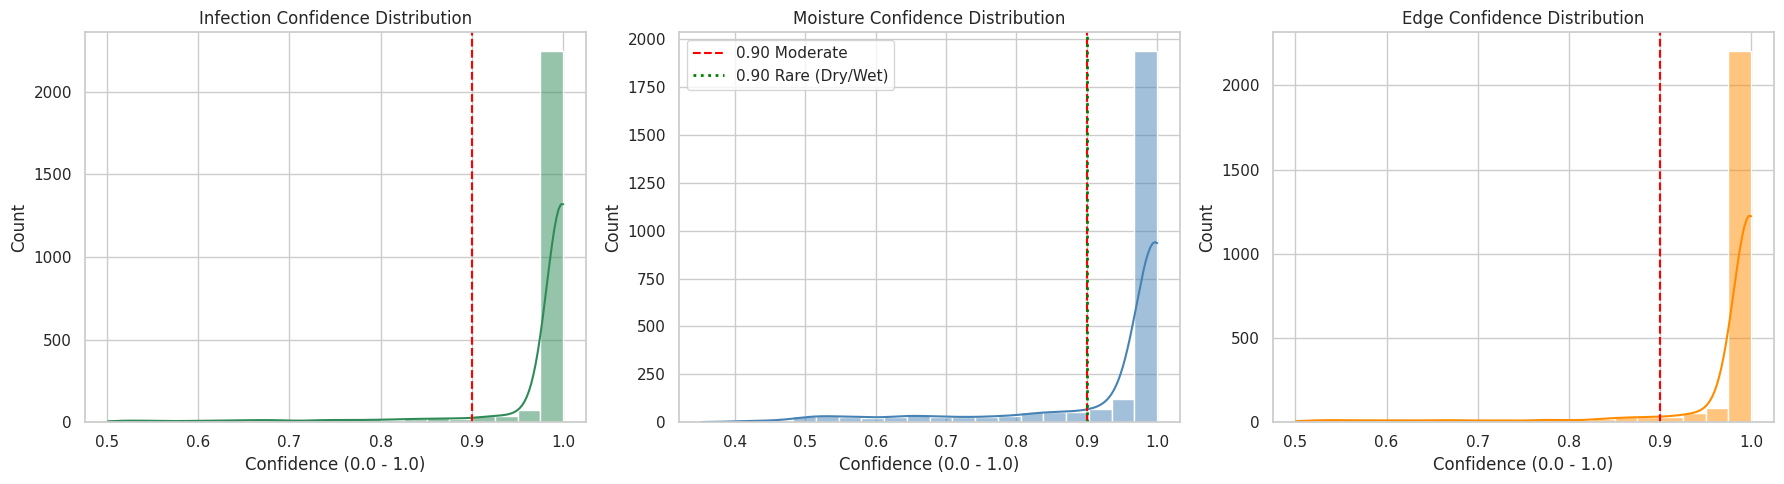

Task       | Mean Confidence | Accepted Confidence Count
---------------------------------------------
INF        | 0.9740       | 2396           
MOIST      | 0.9392       | 2136           
EDGE       | 0.9711       | 2373           


In [ ]:
# Load the results
df = pd.read_csv(SAVE_PATH_CONF_CSV)

# Set the visual style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Task 1: Infection ---
sns.histplot(df['inf_conf'], bins=20, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Infection Confidence Distribution')
axes[0].axvline(0.9, color='red', linestyle='--', label='0.90 Threshold')
axes[0].set_xlabel('Confidence (0.0 - 1.0)')

# --- Task 2: Moisture --- ## Can change the threshold from here
sns.histplot(df['moist_conf'], bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Moisture Confidence Distribution')
axes[1].set_xlabel('Confidence (0.0 - 1.0)')
# For 0.90 confidence score (Moderate)
axes[1].axvline(0.9, color='red', linestyle='--', label='0.90 Moderate')
# For 0.75 confidence score (Too_Dry and Too_Wet)
axes[1].axvline(0.90, color='green', linestyle=':', linewidth=2, label='0.90 Rare (Dry/Wet)')
axes[1].legend()

# --- Task 3: Edge ---
sns.histplot(df['edge_conf'], bins=20, kde=True, ax=axes[2], color='darkorange')
axes[2].set_title('Edge Confidence Distribution')
axes[2].axvline(0.9, color='red', linestyle='--', label='0.90 Threshold')
axes[2].set_xlabel('Confidence (0.0 - 1.0)')

plt.tight_layout()
plt.show()

# --- Print Summary Statistics ---
tasks = ['inf', 'moist', 'edge']
print(f"{'Task':<10} | {'Mean Confidence':<12} | {'Accepted Confidence Count':<15}")
print("-" * 45)

for task in tasks:
    mean_val = df[f'{task}_conf'].mean()

    if task == 'moist':
        # Dynamic count: 0.9 for Moderate (1), 0.75 for Dry/Wet (0, 2)
        count = len(df[
            ((df['moist_label'] == 1) & (df['moist_conf'] >= 0.90)) |
            ((df['moist_label'].isin([0, 2])) & (df['moist_conf'] >= 0.90))
        ])
    else:
        # Standard count: 0.9 for everything else
        count = len(df[df[f'{task}_conf'] >= 0.90])

    print(f"{task.upper():<10} | {mean_val:<12.4f} | {count:<15}")

## Visualize Joint Filtering data (all 3 tasks with high confidence score)

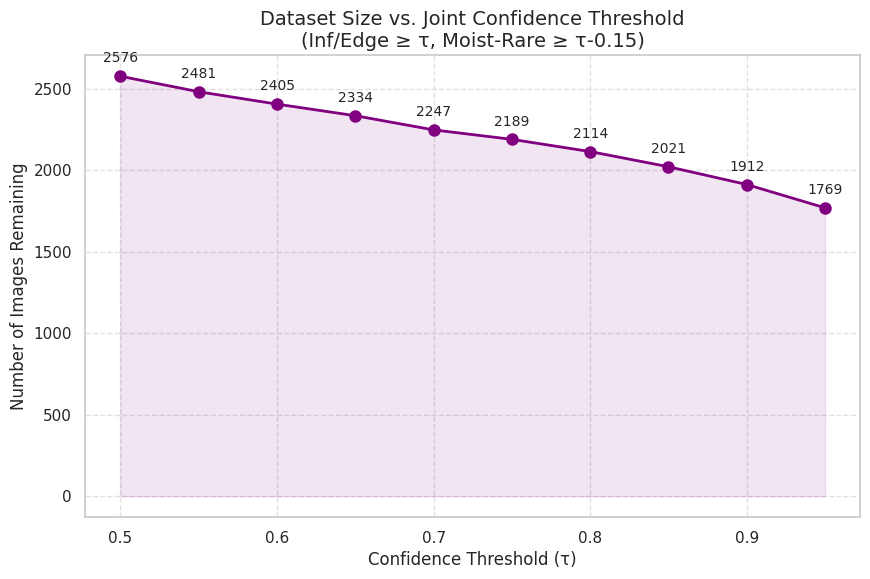

--- RESULTS ---
Total processed images: 2609
Images exceed thresholds for all tasks: 1912


In [ ]:
# Load results
df = pd.read_csv(SAVE_PATH_CONF_CSV)

# Define a range of thresholds to test
thresholds = np.linspace(0.5, 0.95, 10)
joint_counts = []

for t in thresholds:

    # Maintain the 0.15 offset for rare classes (Dry=0, Wet=2)
    t_rare = max(0, t - 0.15)

    # Count images where Inf and Edge meet 't',
    # and Moisture meets its specific dynamic threshold
    count = len(df[
        (df['inf_conf'] >= t) &
        (df['edge_conf'] >= t) &
        (
            ((df['moist_label'] == 1) & (df['moist_conf'] >= t)) |        # Moderate
            ((df['moist_label'].isin([0, 2])) & (df['moist_conf'] >= t_rare)) # Dry/Wet
        )
    ])
    joint_counts.append(count)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, joint_counts, marker='o', color='purple', linewidth=2, markersize=8)
plt.fill_between(thresholds, joint_counts, color='purple', alpha=0.1)

plt.title('Dataset Size vs. Joint Confidence Threshold\n(Inf/Edge ≥ τ, Moist-Rare ≥ τ-0.15)', fontsize=14)
plt.xlabel('Confidence Threshold (τ)', fontsize=12)
plt.ylabel('Number of Images Remaining', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the specific points
for i, val in enumerate(joint_counts):
    plt.annotate(f"{val}", (thresholds[i], joint_counts[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

# Print the final count for the 0.9 case
dynamic_total = joint_counts[8]
print(f"--- RESULTS ---")
print(f"Total processed images: {len(df)}")
print(f"Images exceed thresholds for all tasks: {dynamic_total}")

## Filter the high confidence score data

In [ ]:
# This cell only run for first iteration (as it no need to compare with previous iteration)

# Load results
df_full = pd.read_csv(SAVE_PATH_CONF_CSV)

# Create a copy for the filtered data
df_filtered = df_full.copy()

# Apply thresholds
INF_THRESH = 0.90
EDGE_THRESH = 0.90
MOIST_MODERATE_THRESH = 0.90
MOIST_RARE_THRESH = 0.90


# Set labels to -1 if confidence is too low
df_filtered.loc[df_filtered['inf_conf'] < INF_THRESH, 'inf_label'] = -1
df_filtered.loc[df_filtered['edge_conf'] < EDGE_THRESH, 'edge_label'] = -1

# Filter Moderate class
is_moderate = (df_filtered['moist_label'] == 1)
df_filtered.loc[is_moderate & (df_filtered['moist_conf'] < MOIST_MODERATE_THRESH), 'moist_label'] = -1

# Filter Rare classes (Rescue)
is_rare = (df_filtered['moist_label'].isin([0, 2]))
df_filtered.loc[is_rare & (df_filtered['moist_conf'] < MOIST_RARE_THRESH), 'moist_label'] = -1

# Remove images where ALL three tasks are now -1 (useless images)
df_filtered = df_filtered[~((df_filtered['inf_label'] == -1) &
                            (df_filtered['moist_label'] == -1) &
                            (df_filtered['edge_label'] == -1))]

# Standardize the column naming
df_filtered = df_filtered.rename(columns={
    'inf_label': 'Final_Inf',
    'moist_label': 'Final_Moist',
    'edge_label': 'Final_Edge'
})

# Save the final training file
CLEAN_SSL_CSV = '/content/drive/MyDrive/Wound_Assessment/SSL_Training_Labels_Filtered_Roun.csv'
df_filtered.to_csv(CLEAN_SSL_CSV, index=False)

print(f"Original: {len(df_full)} images")
print(f"Kept for training: {len(df_filtered)} images")

Original: 2609 images
Kept for training: 1640 images


## Clean SSL Pseudo Labels (Compare R2 with R1)

In [ ]:
# 1. Load the two iterations
R1_SAVE_PATH_CONF_CSV = '/content/drive/MyDrive/Wound_Assessment/SSL_WeightedCrossEntropy_pred_results/SSL_Pseudo_Labels_With_Confidence_Round3.csv'
df_r1 = pd.read_csv(R1_SAVE_PATH_CONF_CSV)
df_r2 = pd.read_csv(SAVE_PATH_CONF_CSV)

# 2. Merge on filename
comparison_df = pd.merge(df_r1, df_r2, on='filename', suffixes=('_r1', '_r2'))

tasks = ['inf', 'moist', 'edge']
GLOBAL_THRESHOLD = 0.90
MOIST_RARE_THRESHOLD = 0.90

# Build a new dataframe image by image
new_rows = []

stats = {t: {'improved': 0, 'dropouts': 0, 'flips': 0, 'kept': 0} for t in tasks}

for _, row in comparison_df.iterrows():
    new_entry = {'filename': row['filename']}
    valid_task_count = 0

    for t in tasks:
        conf_r1 = row[f'{t}_conf_r1']
        conf_r2 = row[f'{t}_conf_r2']
        pred_r1 = row[f'{t}_label_r1']
        pred_r2 = row[f'{t}_label_r2']

        new_entry[f'{t}_conf_Final'] = conf_r2

        current_threshold = GLOBAL_THRESHOLD

        if t == 'moist' and pred_r2 in [0, 2]:
            current_threshold = MOIST_RARE_THRESHOLD

        # LOGIC GATE: Is the new prediction confident?
        if conf_r2 >= current_threshold:
            # CHECK FOR FLIPS: Was it confident before but now the label changed?
            if conf_r1 >= GLOBAL_THRESHOLD and pred_r1 != pred_r2:
                stats[t]['flips'] += 1
                new_entry[f'Final_{t.capitalize()}'] = -1
            else:
                # IT'S A KEEPER: Either a 'Consistent' label or a 'New Improved'
                if conf_r1 < current_threshold:
                    stats[t]['improved'] += 1
                else:
                    stats[t]['kept'] += 1

                new_entry[f'Final_{t.capitalize()}'] = int(pred_r2)
                new_entry[f'{t}_conf_Final'] = conf_r2
                valid_task_count += 1
        else:
            # NOT CONFIDENT: Set to -1 so the loss function ignores it
            if conf_r1 >= GLOBAL_THRESHOLD:
                stats[t]['dropouts'] += 1
            new_entry[f'Final_{t.capitalize()}'] = -1

    # Only keep the image if it has at least ONE valid label
    if valid_task_count > 0:
        new_rows.append(new_entry)

# 3. Create the Final Round 2 Dataset
df_iteration_2 = pd.DataFrame(new_rows)

# 4. Print Multi-Task Report
print(f"       MULTI-TASK DRIFT REPORT (ROUND 3 -> 4_0.90) (adjusted conf. score)")
for t in tasks:
    print(f"Task: {t.upper()}")
    print(f"  New Improved Data: {stats[t]['improved']}")
    print(f"  Dropouts:      {stats[t]['dropouts']}")
    print(f"  Label Flips:   {stats[t]['flips']}")
    print(f"  Total Valid:   {len(df_iteration_2[df_iteration_2[f'Final_{t.capitalize()}'] != -1])}")
    print("-" * 30)

print(f"\nTOTAL IMAGES FOR ROUND 4 TRAINING (adjusted conf. score): {len(df_iteration_2)}")
CLEAN_SSL_CSV = '/content/drive/MyDrive/Wound_Assessment/SSL_Training_Labels_Filtered_Round4_0.90.csv'
df_iteration_2.to_csv(CLEAN_SSL_CSV, index=False)

       MULTI-TASK DRIFT REPORT (ROUND 3 -> 4_0.90) (adjusted conf. score)
Task: INF
  New Improved Data: 1070
  Dropouts:      1
  Label Flips:   0
  Total Valid:   2396
------------------------------
Task: MOIST
  New Improved Data: 1779
  Dropouts:      0
  Label Flips:   0
  Total Valid:   2136
------------------------------
Task: EDGE
  New Improved Data: 828
  Dropouts:      5
  Label Flips:   0
  Total Valid:   2373
------------------------------

TOTAL IMAGES FOR ROUND 4 TRAINING (adjusted conf. score): 2572


## Merge Master Training Data

In [ ]:
# 1. Load the Original Supervised Data (107 images)
df_original = pd.read_csv('../data/metadata/metadata_with_folds.csv')
df_original['source'] = 'expert'
df_original['image_dir'] = '../data/segmented_images/Segmented_Dataset_Final_v2/' # Update this to your original image path

# 2. Load your New Filtered SSL Data
df_ssl = pd.read_csv('/content/drive/MyDrive/Wound_Assessment/SSL_Training_Labels_Filtered_Round4_0.90.csv')
df_ssl['source'] = 'pseudo'
df_ssl['image_dir'] = PROCESSED_SSL_DIR # This points to your 224x224 processed folder

# 3. Combine them
master_df = pd.concat([df_original, df_ssl], ignore_index=True)

# 4. Save model
MASTER_CSV_PATH = '../Training_Master_Sheets/Training_Master_Round4_0.90.csv'
master_df.to_csv(MASTER_CSV_PATH, index=False)

print(f"Expert Images: {len(df_original)}")
print(f"Pseudo Images: {len(df_ssl)}")
print(f"Total Training Samples: {len(master_df)}")

Expert Images: 107
Pseudo Images: 2572
Total Training Samples: 2679


In [ ]:
# Check how many 'real' labels the Master Training sheet has for each task
print("Active Labels for Master Training (excluding -1):")
for task in ['Final_Inf', 'Final_Moist', 'Final_Edge']:
    active_count = len(master_df[master_df[task] != -1])
    print(f"{task}: {active_count} samples")

Active Labels for Master Training (excluding -1):
Final_Inf: 2502 samples
Final_Moist: 2243 samples
Final_Edge: 2475 samples


/tmp/ipykernel_689/1915805337.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=master_df['Final_Inf'].map({0:'Not_Infected', 1:'Infected', -1:'Missing'}),
/tmp/ipykernel_689/1915805337.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=master_df['Final_Moist'].map({0:'Too_Dry', 1:'Moderate', 2:'Too_Wet', -1:'Missing'}),
/tmp/ipykernel_689/1915805337.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=master_df['Final_Edge'].map({0:'Not_Advancing', 1:'Advancing', -1:'Missing'}),


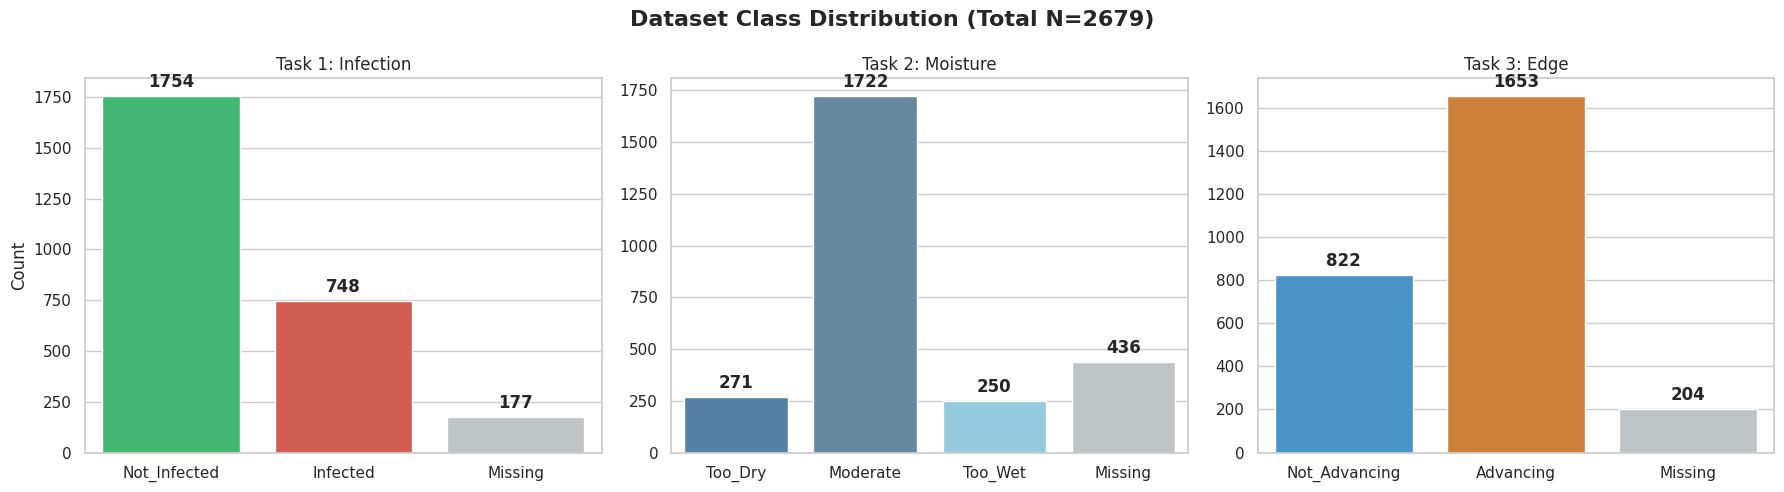

In [ ]:
# 1. Setup the visual style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# 2. Create the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Dataset Class Distribution (Total N={len(master_df)})', fontsize=16, weight='bold')

# --- CHART 1: INFECTION ---
sns.countplot(x=master_df['Final_Inf'].map({0:'Not_Infected', 1:'Infected', -1:'Missing'}),
              ax=axes[0], palette=['#2ecc71', '#e74c3c', '#bdc3c7'], order=['Not_Infected', 'Infected', 'Missing'])
axes[0].set_title("Task 1: Infection")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

# Add numbers on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')

# --- CHART 2: MOISTURE ---
sns.countplot(x=master_df['Final_Moist'].map({0:'Too_Dry', 1:'Moderate', 2:'Too_Wet', -1:'Missing'}),
              ax=axes[1], palette=['#4682B4', '#5D8AA8','#87CEEB', '#bdc3c7'], order=['Too_Dry', 'Moderate', 'Too_Wet', 'Missing'])
axes[1].set_title("Task 2: Moisture")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Add numbers on bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')

# --- CHART 3: EDGE ---
sns.countplot(x=master_df['Final_Edge'].map({0:'Not_Advancing', 1:'Advancing', -1:'Missing'}),
              ax=axes[2], palette=['#3498db', '#e67e22', '#bdc3c7'], order=['Not_Advancing', 'Advancing', 'Missing'])
axes[2].set_title("Task 3: Edge")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

# Add numbers on bars
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()